# Readout Fidelity Correction (IBU Demo)

This notebook demonstrates **readout-fidelity correction** using an Iterative Bayesian Update (IBU) method on an included two-qubit dataset.

IBU is a practical way to invert a measured readout confusion matrix when the naive matrix inverse would be unstable or would yield small negative probabilities.

## Inputs
- `data/singlet_Ux_t_list_1218.csv`
- `data/singlet_Ux_P_1218.csv` (readout-corrected populations with columns `P_00,P_01,P_10,P_11`)

## Output
- `figures/readout_fidelity_correction.png`

```mermaid
flowchart LR
  t["True distribution t"] -->|"Apply readout<br/>(confusion matrix R)"| m["Measured distribution m"]
  m --> ibu["IBU iterations<br/>(using R)"] --> that["Estimated corrected distribution"]
```


In [1]:
import os
from pathlib import Path

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
plt.rcParams['text.usetex'] = _HAS_TEX
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if plt.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')




Working directory: /Users/chellymac/projects/positronium-sensing


## Readout confusion matrix

The joint two-qubit readout is characterized by a **confusion matrix** `R` whose entries are conditional probabilities
$$R_{m,t} = P(\text{measured}=m\mid\text{true}=t).$$

In this notebook we use the computational-basis ordering `|00⟩, |01⟩, |10⟩, |11⟩` for both the measured and true labels.

![readout_fidelity_Q1Q2](../figures/readout_fidelity_Q1Q2.png "Readout Fidelity Q1Q2")

In [2]:
# Numpy array representation of the two-qubit readout confusion matrix.
# Convention: R[measured_state, true_state] = P(measured | true).
R = np.array([
    [0.911, 0.052, 0.034, 0.002],
    [0.068, 0.920, 0.004, 0.042],
    [0.019, 0.001, 0.892, 0.055],
    [0.002, 0.027, 0.071, 0.900]
])


## Demonstration on an included dataset

To make the demo self-contained, we start from the released **readout-corrected** probabilities, apply `R` to generate a **raw/measured** distribution, and then run IBU to recover the corrected distribution. The final sanity check compares the recovered distribution against the released corrected CSV.


In [3]:
# IBU correction (iterative Bayesian unfolding)
def IBU_correction(R, m, N=10):
    """Iterative Bayesian Update (IBU) for readout correction.
    
    Parameters
    ----------
    R : array, shape (n_meas, n_true)
        Confusion matrix with R[measured, true] = P(measured | true).
    m : array, shape (..., n_meas)
        Measured probability distributions (last axis enumerates measured outcomes).
    N : int
        Number of IBU iterations.
    """
    shape = m.shape[:-1]
    n_m, n_t = R.shape
    m = m.reshape((-1, n_m))

    R_mask = np.any(R != 0.0, axis=1)
    R = R[R_mask, :]
    m = m[:, R_mask]
    m_row_sum = np.sum(m, axis=1).reshape((-1, 1))
    m /= m_row_sum

    t = np.full((len(m), n_t), 1 / n_t)
    for _ in range(N):
        t = np.tensordot((m / np.tensordot(t, R, (1, 1))), R, (1, 0)) * t
    return t.reshape(shape + (n_t,))


Maximum error between the corrected data and the data loaded from the csv file = 0.003934478551242975  (should be 10^-3 order of magnitude)


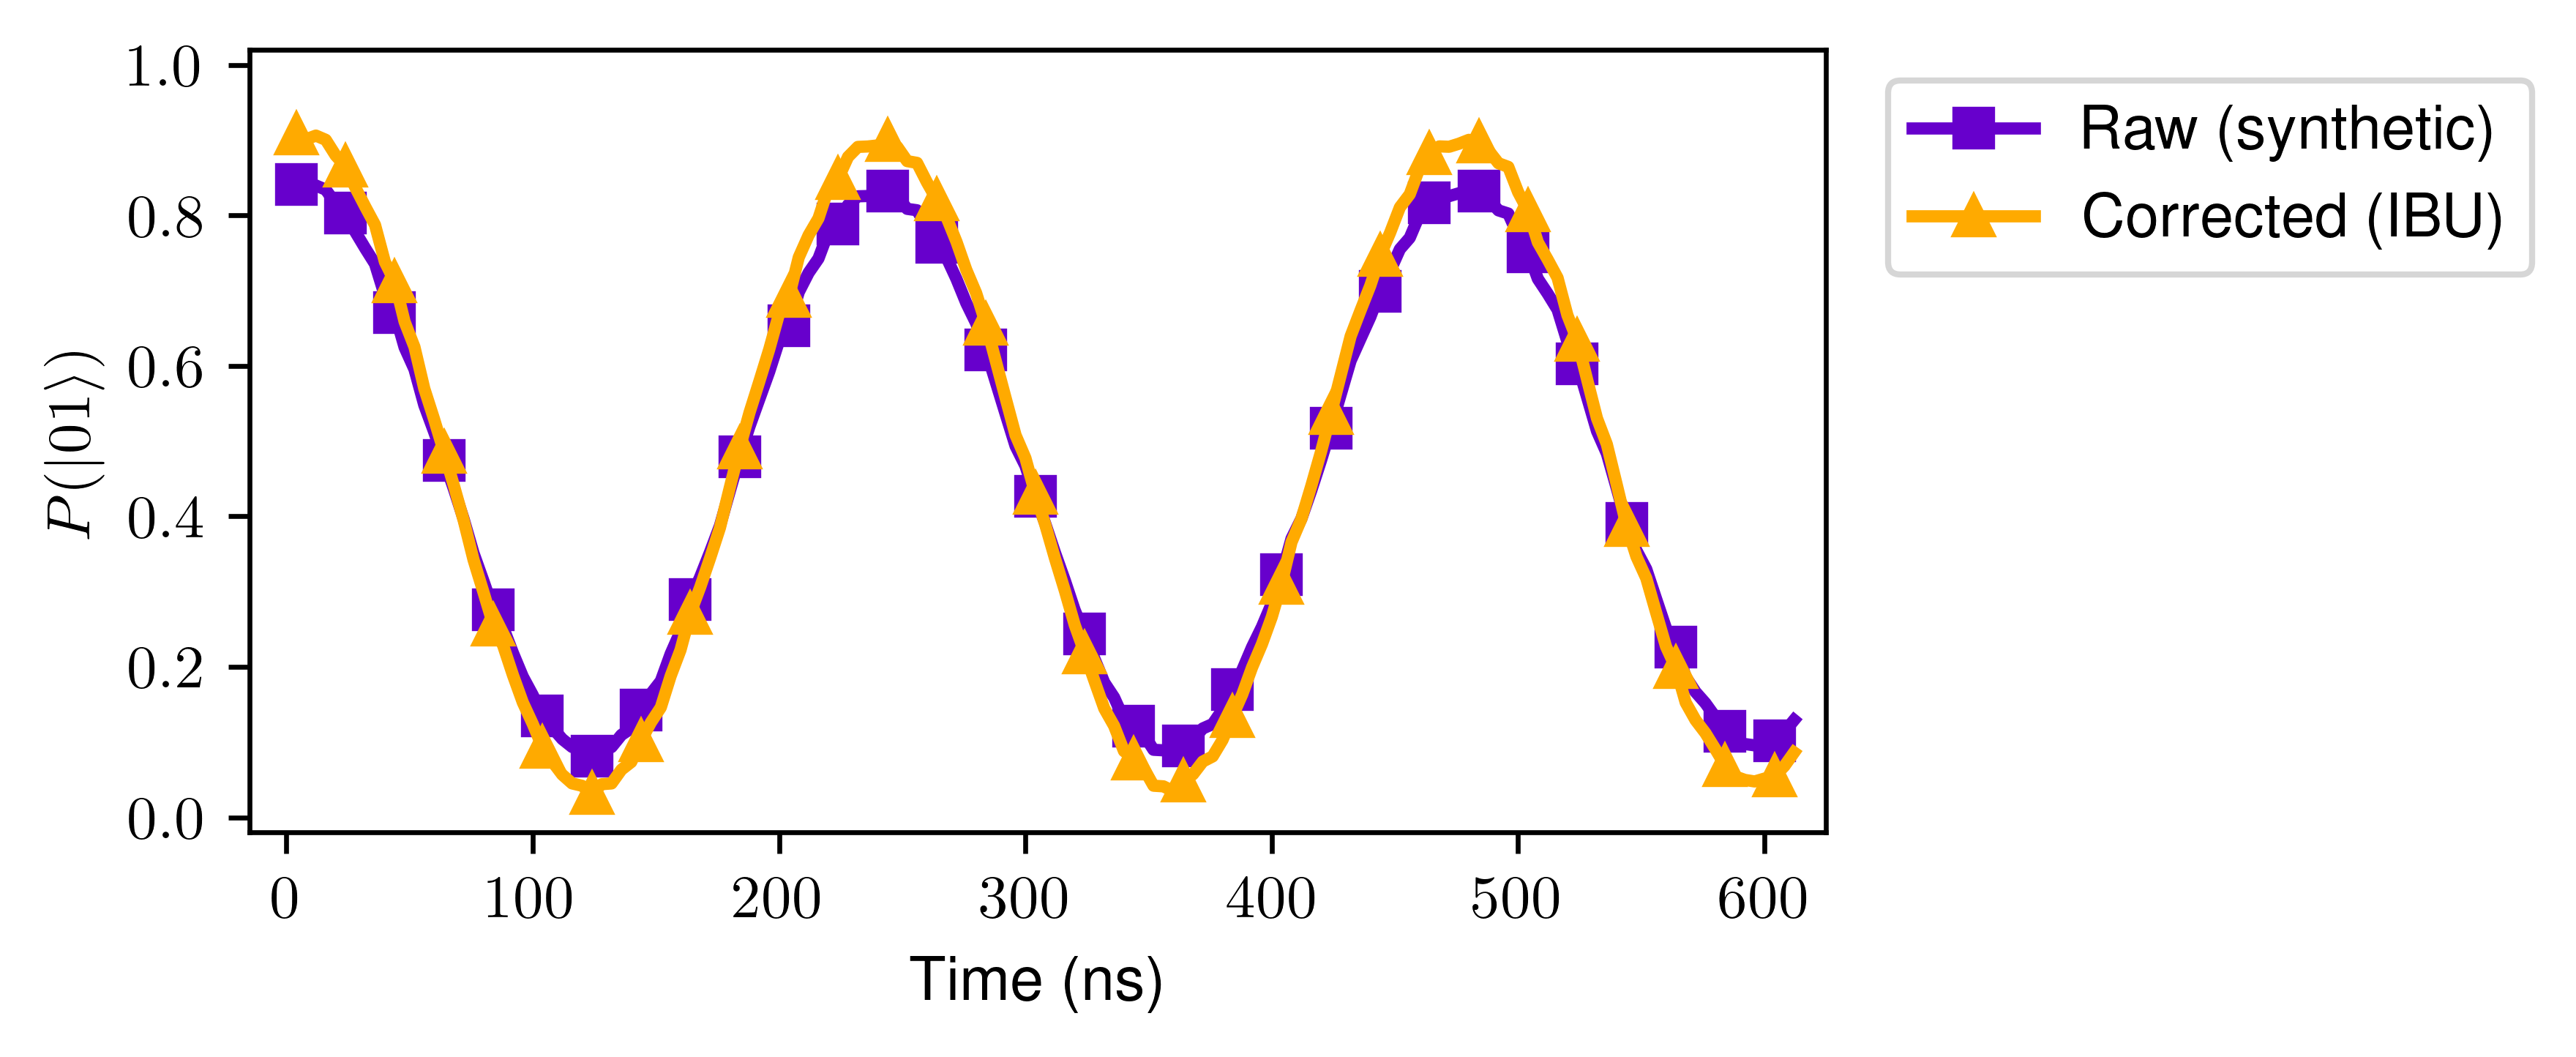

In [ ]:
# Load the released readout-corrected probabilities P_corr(t).
t_list_ns = np.loadtxt(r'data/singlet_Ux_t_list_1218.csv', delimiter=",", skiprows=1)
P_corr = np.loadtxt(r'data/singlet_Ux_P_1218.csv', delimiter=",", skiprows=1)

# Forward model: apply the confusion matrix to obtain a raw/measured distribution.
P_raw = np.einsum(R, [0, 1], P_corr, [2, 1], [2, 0])
# Apply IBU to recover an estimate of the corrected distribution.
P_corrected = IBU_correction(R, P_raw)

# Sanity check: recovered corrected distribution should match the released corrected CSV.
print(f"Maximum error between the corrected data and the data loaded from the csv file = {np.max(np.abs(P_corrected - P_corr))}  (should be 10^-3 order of magnitude)")

purple = '#6700CC'
orange = '#FFAA00'
gray = '#777777'

fig, ax = plt.subplots(figsize=(6, 2.5), dpi=600)
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.1, top=0.98)
plt.plot(t_list_ns, P_raw[:, 1], color=purple, marker='s', label='Raw', linewidth=2, markevery=5)
plt.plot(t_list_ns, P_corrected[:, 1], color=orange, marker='^', label='Corrected (IBU)', linewidth=2, markevery=5)
plt.xlim(-15, 625)
plt.ylim(-0.02, 1.02)
plt.xlabel('Time (ns)')
plt.ylabel(fr'$P({ket_01})$')
plt.legend(bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()






In [5]:
fig.savefig(r"./figures/readout_fidelity_correction.png")
